# Mcardiac_EA results

Epicardial-cell example.

## Settings

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents)
                    if (path / "experiments").is_dir() and (path / "lrpairs").is_dir())
sys.path.insert(0, str(PROJECT_ROOT / "experiments"))

from pathlib import Path
import yaml

DATASET = 'heart_slide_seq'
CWD = Path.cwd().resolve()
EXPERIMENT_DIR = CWD if (CWD / "config.yaml").is_file() else CWD / "experiments" / "Mcardiac_EA"
REPO_ROOT = EXPERIMENT_DIR.parents[1]
import sys

CONFIG = yaml.safe_load(
    (EXPERIMENT_DIR / "config.yaml").read_text(encoding="utf-8")
)

def experiment_path(value):
    path = Path(value)
    return path if path.is_absolute() else (EXPERIMENT_DIR / path).resolve()

RUN_ROOT = experiment_path(CONFIG["run_root"])
SCANVI_DIR = experiment_path(CONFIG["scanvi_dir"])
SCANVI_ADATA = experiment_path(CONFIG["input_path"])
STAGE1_CHECKPOINT_ROOT = experiment_path(CONFIG["stage1_checkpoint"])

import json
sys.path.insert(0, str(REPO_ROOT))
from _shared.frame_gallery import load_gallery, plot_gallery

PALETTE = json.loads((EXPERIMENT_DIR / "colors.json").read_text())
ROUTES = [tuple(route) for route in CONFIG["routes"]]
INPUT_PATH = SCANVI_ADATA
INTERVAL = 1


## Simulation frames

In [2]:
segments = []
for src, tgt in ROUTES:
    route = f"{src}_to_{tgt}"
    frame_dir = RUN_ROOT / "simulation" / route
    segments.append({"src": src, "tgt": tgt, "frame_dir": frame_dir,
                     "checkpoint": STAGE1_CHECKPOINT_ROOT / route / "checkpoints" / "best.pt"})

panels = load_gallery(INPUT_PATH, 'sample', CONFIG["celltype_source_key"],
                      segments, dimension=CONFIG["spatial_dimension"], interval=INTERVAL)


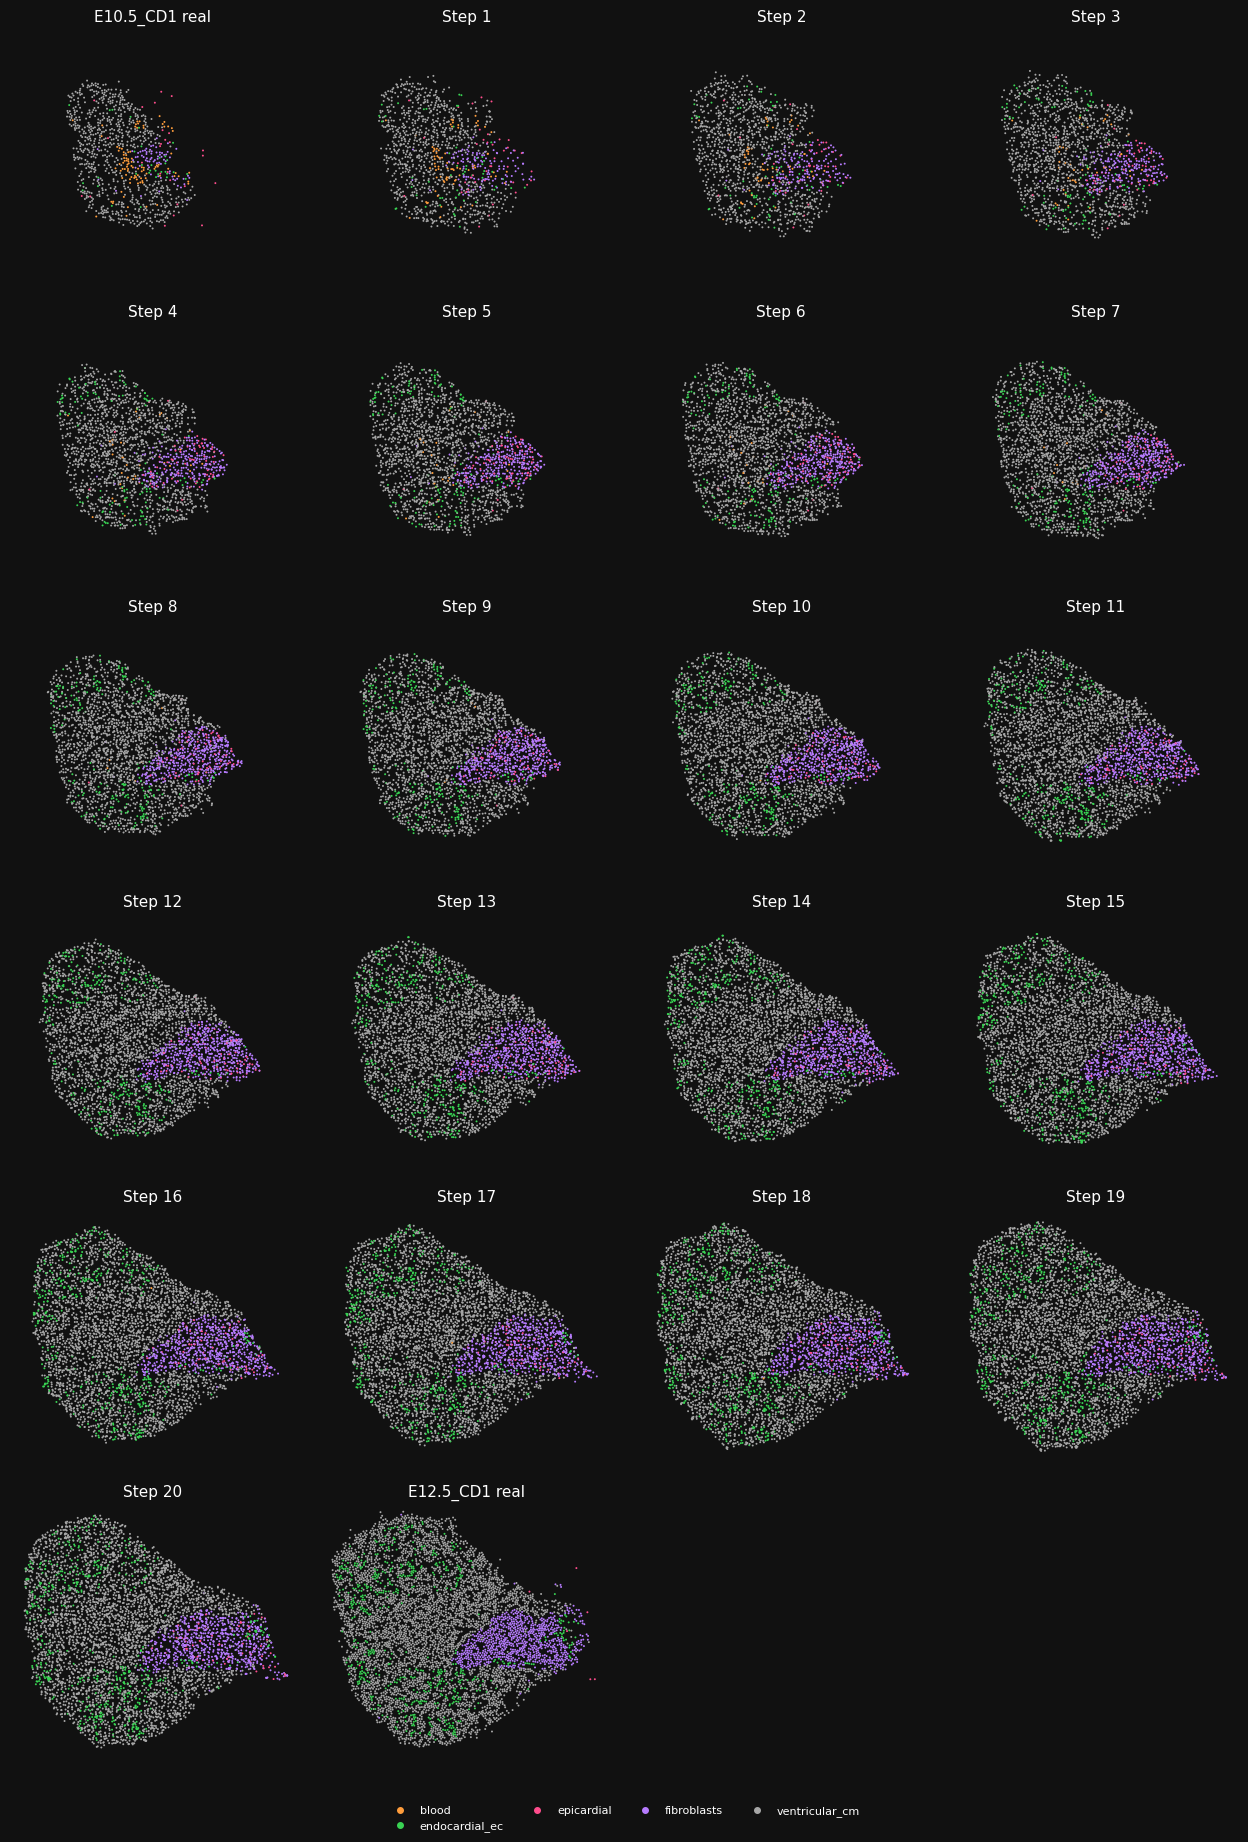

In [3]:
fig = plot_gallery(panels, PALETTE, dimension=CONFIG["spatial_dimension"],
                   flip_y=True, point_size=2)
import matplotlib.pyplot as plt
plt.show()